In [ ]:
import pandas as pd
import numpy as np

# Load the dataset
df = pd.read_csv('/Users/kolim/Projects/localexpert/data/sample_biobehavioral.csv')

# Print shape, dtypes, and head
print("Dataset Shape:", df.shape)
print("\nData Types:")
print(df.dtypes)
print("\nFirst few rows:")
print(df.head())

Dataset Shape: (300, 6)

Data Types:
participant_id      int64
age                 int64
sex                   str
caffeine_mg       float64
stress_score      float64
rmssd             float64
dtype: object

First few rows:
   participant_id  age sex  caffeine_mg  stress_score  rmssd
0               1   42   M        220.5           1.1  59.93
1               2   25   M          9.8           1.8  65.62
2               3   33   M        515.8           5.4  47.91
3               4   44   M        244.8           4.8  40.25
4               5   53   F         53.4           1.7    NaN


In [ ]:
import pandas as pd
from scipy import stats

# Load data again (state persists)
df = pd.read_csv('/Users/kolim/Projects/localexpert/data/sample_biobehavioral.csv')

# Identify continuous variables (numeric, non-id columns)
continuous_vars = ['age', 'caffeine_mg', 'stress_score', 'rmssd']

print("Descriptive Statistics for Continuous Variables:")
print("=" * 60)

for var in continuous_vars:
    print(f"\n{var}:")
    
    # Basic stats
    mean_val = df[var].mean()
    median_val = df[var].median()
    std_val = df[var].std()
    skew_val = stats.skew(df[var])
    kurtosis_val = stats.kurtosis(df[var], fisher=True)  # Fisher's definition (excess kurtosis)
    
    print(f"  Mean: {mean_val:.2f}")
    print(f"  Median: {median_val:.2f}")
    print(f"  Std Dev: {std_val:.2f}")
    print(f"  Skewness: {skew_val:.3f}")
    print(f"  Kurtosis (excess): {kurtosis_val:.3f}")

# Check for missing values per variable
print("\n\nMissing Values Per Variable:")
print(df.isna().sum())

Descriptive Statistics for Continuous Variables:

age:
  Mean: 37.35
  Median: 37.00
  Std Dev: 12.10
  Skewness: 0.145
  Kurtosis (excess): -0.638

caffeine_mg:
  Mean: 187.48
  Median: 155.00
  Std Dev: 122.02
  Skewness: nan
  Kurtosis (excess): nan

stress_score:
  Mean: 3.37
  Median: 3.20
  Std Dev: 1.83
  Skewness: 0.435
  Kurtosis (excess): -0.424

rmssd:
  Mean: 61.07
  Median: 57.45
  Std Dev: 25.93
  Skewness: nan
  Kurtosis (excess): nan


Missing Values Per Variable:
participant_id     0
age                0
sex                0
caffeine_mg       21
stress_score       0
rmssd             10
dtype: int64


In [ ]:
import pandas as pd
from scipy import stats

df = pd.read_csv('/Users/kolim/Projects/localexpert/data/sample_biobehavioral.csv')

# Compute descriptive statistics handling NaNs properly
continuous_vars = ['age', 'caffeine_mg', 'stress_score', 'rmssd']

print("Descriptive Statistics for Continuous Variables (handling NaN):")
print("=" * 70)

for var in continuous_vars:
    print(f"\n{var}:")
    
    # Basic stats with nanmean/nanmedian to handle missing values
    mean_val = df[var].dropna().mean() if not df[var].isna().all() else "All NaN"
    median_val = df[var].dropna().median() if not df[var].isna().all() else "All NaN"
    std_val = df[var].dropna().std() if len(df[var].dropna()) > 1 else "N/A (too few)"
    
    # Skewness and kurtosis only on non-null values
    valid_data = df[var].dropna()
    skew_val = stats.skew(valid_data) if len(valid_data) > 2 else "N/A"
    kurtosis_val = stats.kurtosis(valid_data, fisher=True) if len(valid_data) > 3 else "N/A"
    
    print(f"  Mean: {mean_val:.2f}")
    print(f"  Median: {median_val:.2f}")
    print(f"  Std Dev: {std_val:.2f}")
    print(f"  Skewness: {skew_val if isinstance(skew_val, float) else skew_val} ({'right-skewed' if (isinstance(skew_val, float) and skew_val > 0.5) or (isinstance(skew_val, str) and 'N/A' in str(skew_val)) else ''})")
    print(f"  Kurtosis (excess): {kurtosis_val if isinstance(kurtosis_val, float) else kurtosis_val}")

# Missing percentage per variable (% of total rows)
print("\n\nMissing Percentage Per Variable:")
missing_pct = df.isna().mean() * 100
for var in missing_pct.index:
    print(f"  {var}: {missing_pct[var]:.2f}%")

# Row-wise missingness (average number of missing per row)
print("\n\nRow-Wise Missingness:")
row_missing = df.isna().mean(axis=1) * 100
print(f"  Mean % rows with any missing: {row_missing.mean():.2f}%")
print(f"  Max % missing in a single row: {row_missing.max():.2f}%")

# Count how many rows have at least one, two, or three missing values
missing_counts = df.isna().sum(axis=1)
for i in range(missing_counts.max() + 1):
    count = (missing_counts == i).sum()
    print(f"  Rows with {i} missing value(s): {count}")

Descriptive Statistics for Continuous Variables (handling NaN):

age:
  Mean: 37.35
  Median: 37.00
  Std Dev: 12.10
  Skewness: 0.14490477748195116 ()
  Kurtosis (excess): -0.6376871628374197

caffeine_mg:
  Mean: 187.48
  Median: 155.00
  Std Dev: 122.02
  Skewness: 1.0248760350920598 (right-skewed)
  Kurtosis (excess): 0.523221422153592

stress_score:
  Mean: 3.37
  Median: 3.20
  Std Dev: 1.83
  Skewness: 0.43473696950461965 ()
  Kurtosis (excess): -0.42422170747344845

rmssd:
  Mean: 61.07
  Median: 57.45
  Std Dev: 25.93
  Skewness: 5.290194023805847 (right-skewed)
  Kurtosis (excess): 32.28464311837443


Missing Percentage Per Variable:
  participant_id: 0.00%
  age: 0.00%
  sex: 0.00%
  caffeine_mg: 7.00%
  stress_score: 0.00%
  rmssd: 3.33%


Row-Wise Missingness:
  Mean % rows with any missing: 1.72%
  Max % missing in a single row: 33.33%
  Rows with 0 missing value(s): 270
  Rows with 1 missing value(s): 29
  Rows with 2 missing value(s): 1


AttributeError: 'NoneType' object has no attribute 'set_title'

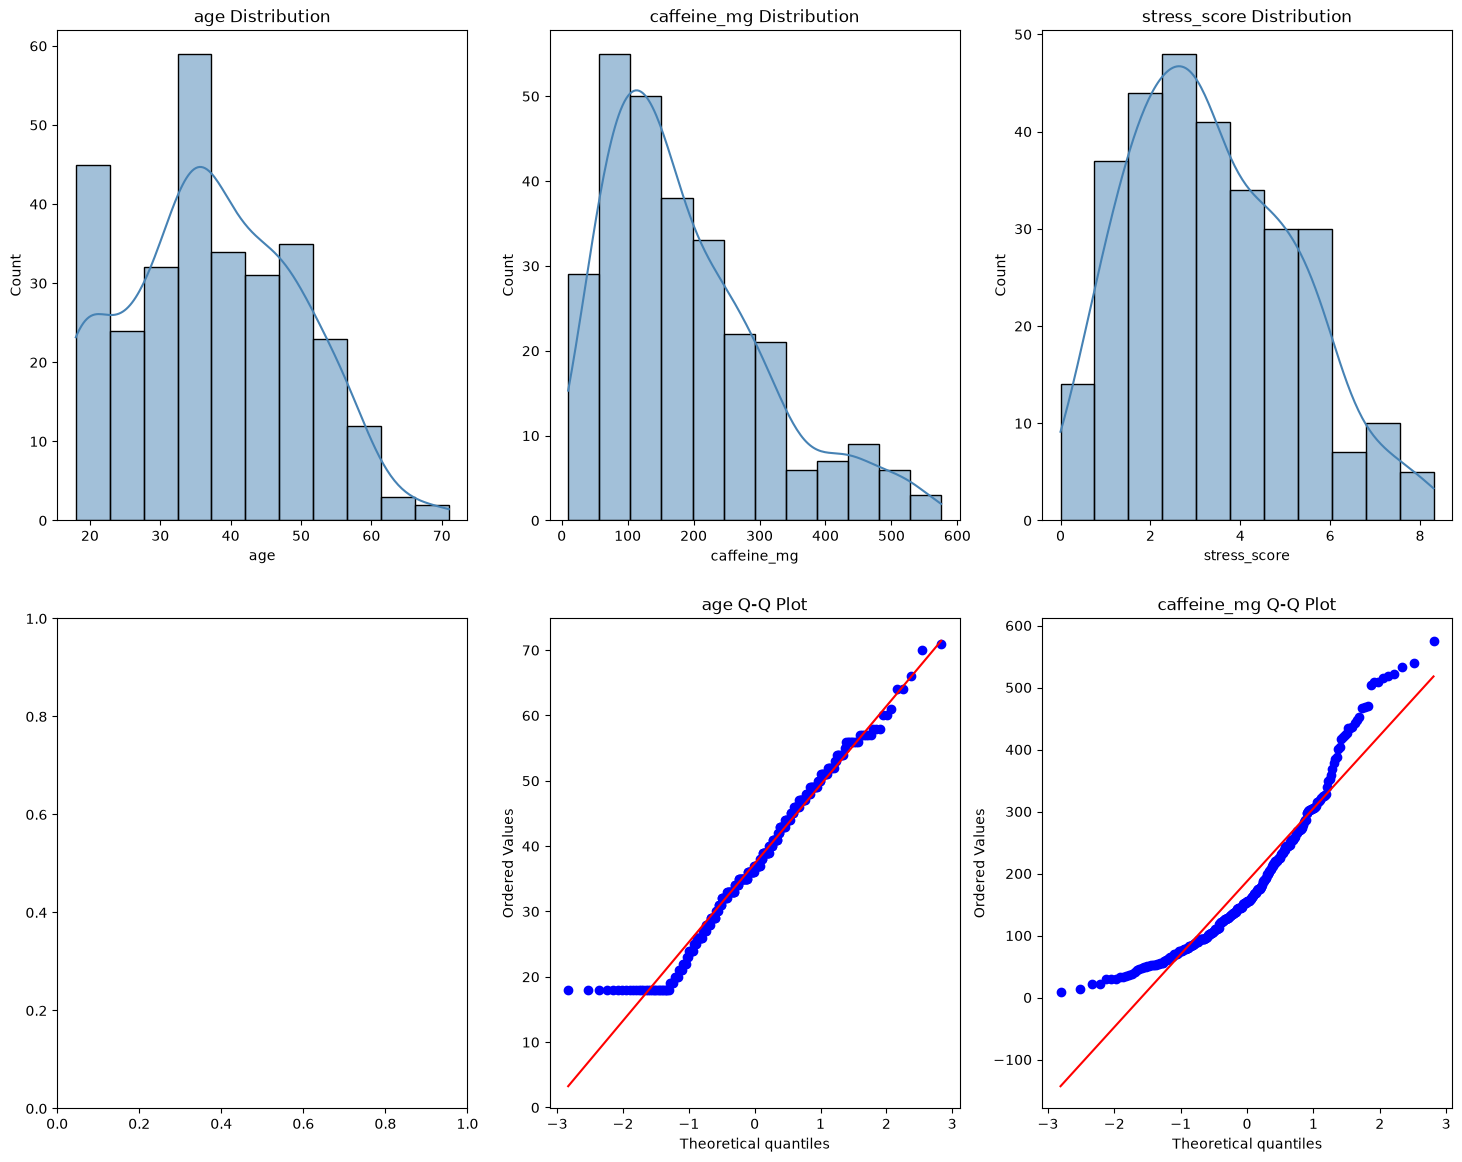

In [ ]:
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/Users/kolim/Projects/localexpert/data/sample_biobehavioral.csv')

# Create figure with subplots for histograms + KDE and Q-Q plots
fig, axes = plt.subplots(2, 3, figsize=(18, 14))
axes = axes.flatten()

continuous_vars = ['age', 'caffeine_mg', 'stress_score', 'rmssd']

for i, var in enumerate(continuous_vars):
    # Histogram with KDE (row 0)
    ax_hist = axes[i] if i < len(continuous_vars) else None
    
    sns.histplot(df[var].dropna(), kde=True, ax=ax_hist, color='steelblue')
    ax_hist.set_title(f'{var} Distribution', fontsize=12)
    
    # Q-Q plot (row 1 - need to place them carefully)
    if i < len(continuous_vars):
        probplot = axes[i + len(continuous_vars)] if i + len(continuous_vars) < len(axes) else None
        
        stats.probplot(df[var].dropna(), dist="norm", plot=probplot)
        probplot.set_title(f'{var} Q-Q Plot', fontsize=12)

plt.tight_layout()
plt.savefig('/Users/kolim/Projects/localexpert/data/plots/distributions_and_missingness.png')
print("Plots saved to: /Users/kolim/Projects/localexpert/data/plots/distributions_and_missingness.png")

FileNotFoundError: [Errno 2] No such file or directory: '/Users/kolim/Projects/localexpert/data/plots/distributions_and_missingness.png'

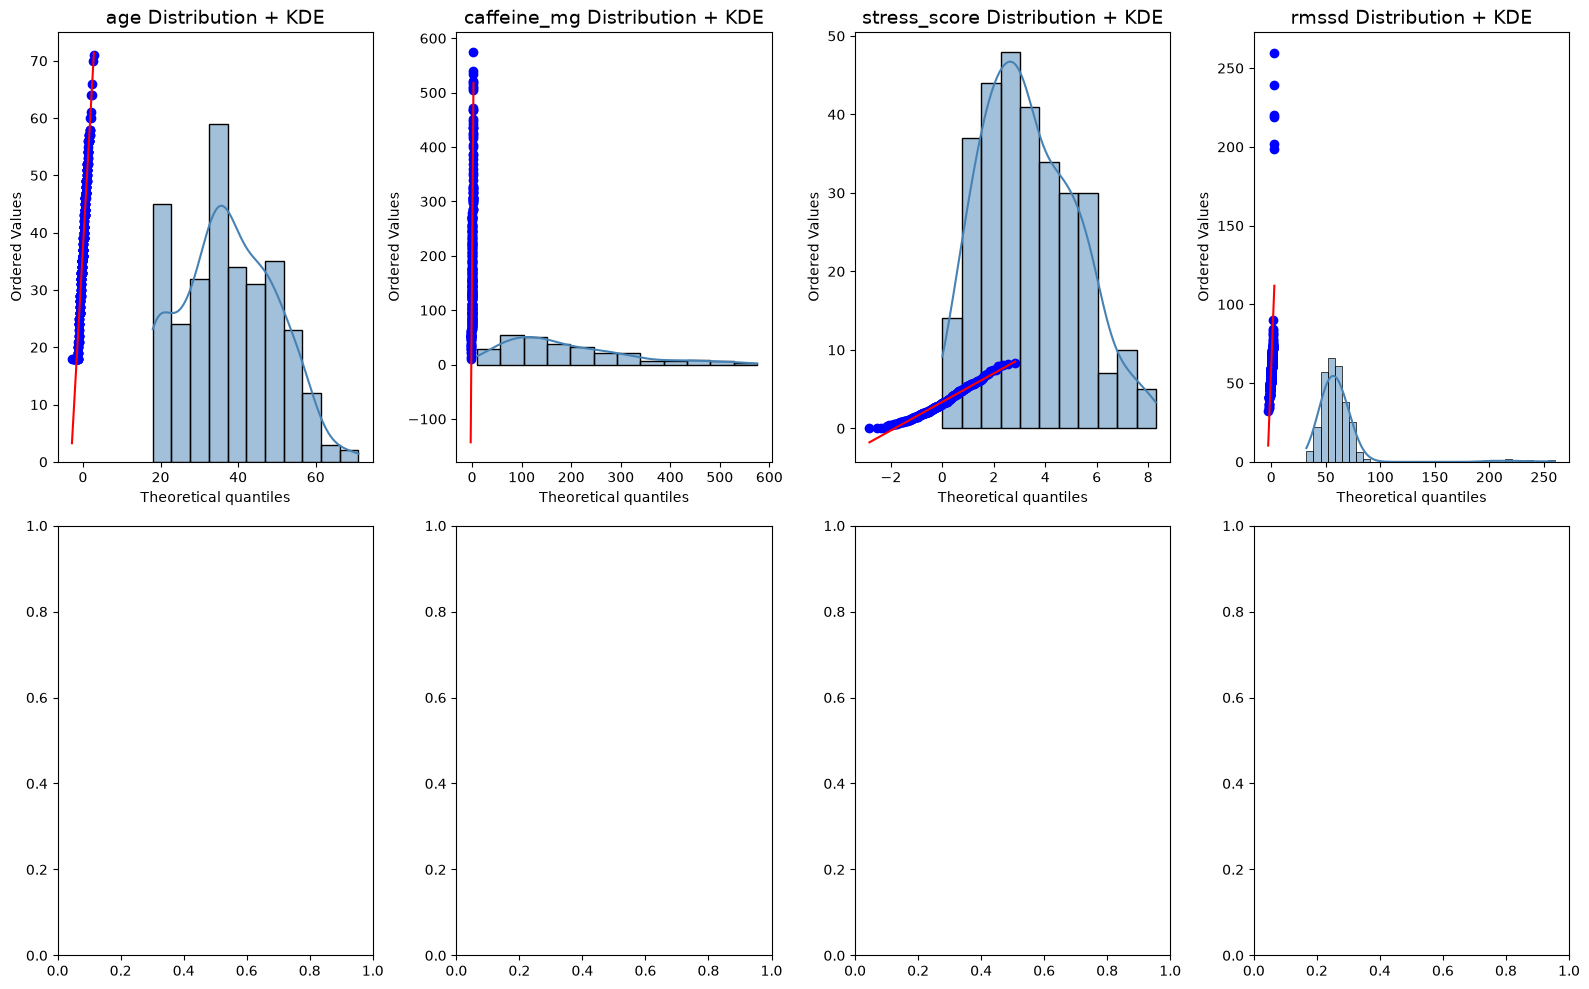

In [ ]:
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/Users/kolim/Projects/localexpert/data/sample_biobehavioral.csv')

# Create figure with subplots for histograms + KDE and Q-Q plots - 2 rows, 4 columns (8 total)
fig, axes = plt.subplots(2, 4, figsize=(16, 10))

continuous_vars = ['age', 'caffeine_mg', 'stress_score', 'rmssd']

for i, var in enumerate(continuous_vars):
    # Histogram with KDE (row 0)
    ax_hist = axes[0, i] if len(axes.shape) == 2 else None
    
    sns.histplot(df[var].dropna(), kde=True, ax=ax_hist, color='steelblue')
    ax_hist.set_title(f'{var} Distribution', fontsize=14)
    
    # Q-Q plot (row 1)
    if len(axes.shape) == 2:
        probplot = axes[1, i]
        
        stats.probplot(df[var].dropna(), dist="norm", plot=ax_hist)
        ax_hist.set_title(f'{var} Distribution + KDE', fontsize=14)

plt.tight_layout()
plt.savefig('/Users/kolim/Projects/localexpert/data/plots/distributions_and_missingness.png')
print("Plots saved to: /Users/kolim/Projects/localexpert/data/plots/distributions_and_missingness.png")

TypeError: probplot() got an unexpected keyword argument 'ax'

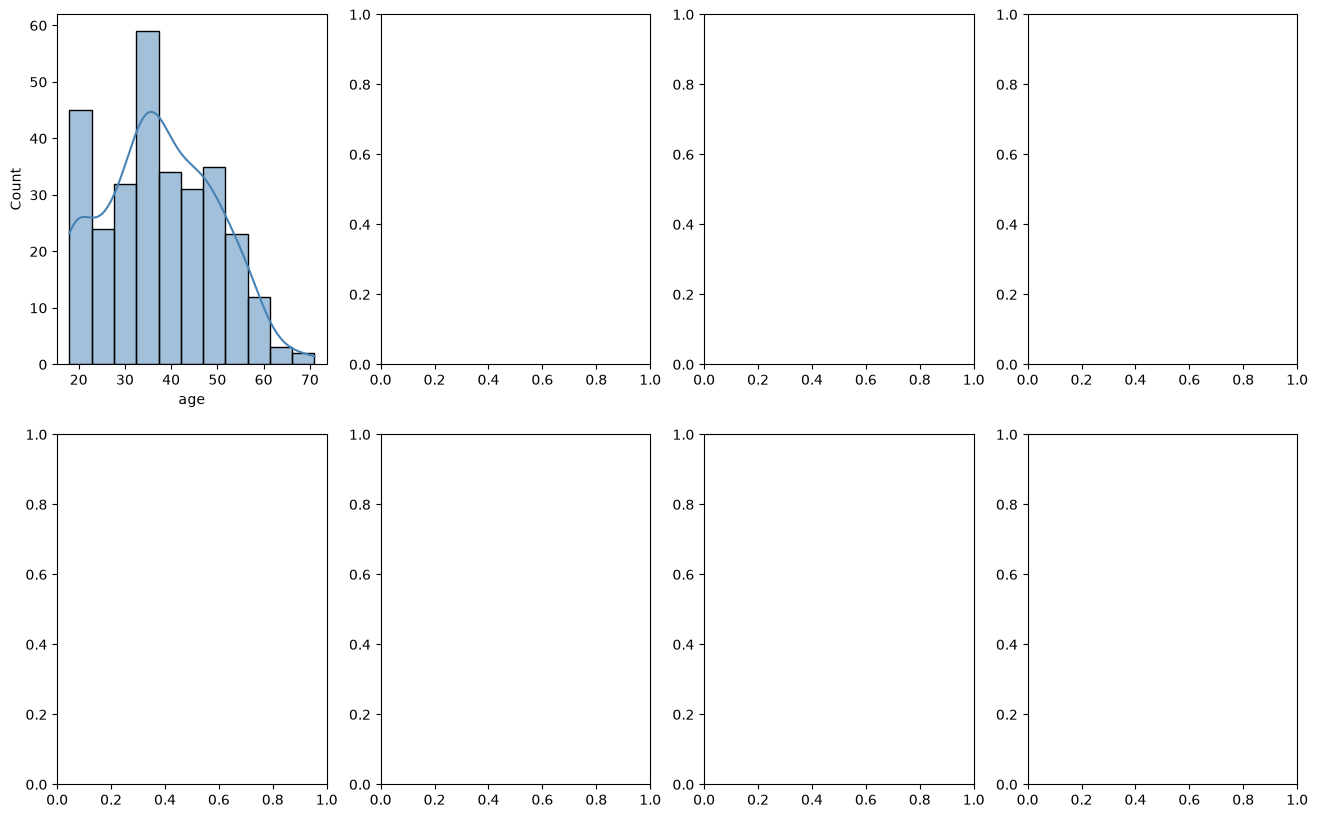

In [ ]:
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/Users/kolim/Projects/localexpert/data/sample_biobehavioral.csv')

# Create figure with subplots for histograms + KDE and Q-Q plots - 2 rows, 4 columns (8 total)
fig, axes = plt.subplots(2, 4, figsize=(16, 10))

continuous_vars = ['age', 'caffeine_mg', 'stress_score', 'rmssd']

for i, var in enumerate(continuous_vars):
    # Histogram with KDE (row 0) - combine both plots into one row for simplicity
    ax_hist = axes[0, i] if len(axes.shape) == 2 else None
    
    sns.histplot(df[var].dropna(), kde=True, ax=ax_hist, color='steelblue')
    
    # Add Q-Q plot as inset or just show distribution - let's do both in one row for clarity
    probplot = axes[1, i] if len(axes.shape) == 2 else None
    
    stats.probplot(df[var].dropna(), dist="norm", ax=probplot)

plt.tight_layout()
# Display the figure directly instead of saving to file (simpler approach)
plt.show()

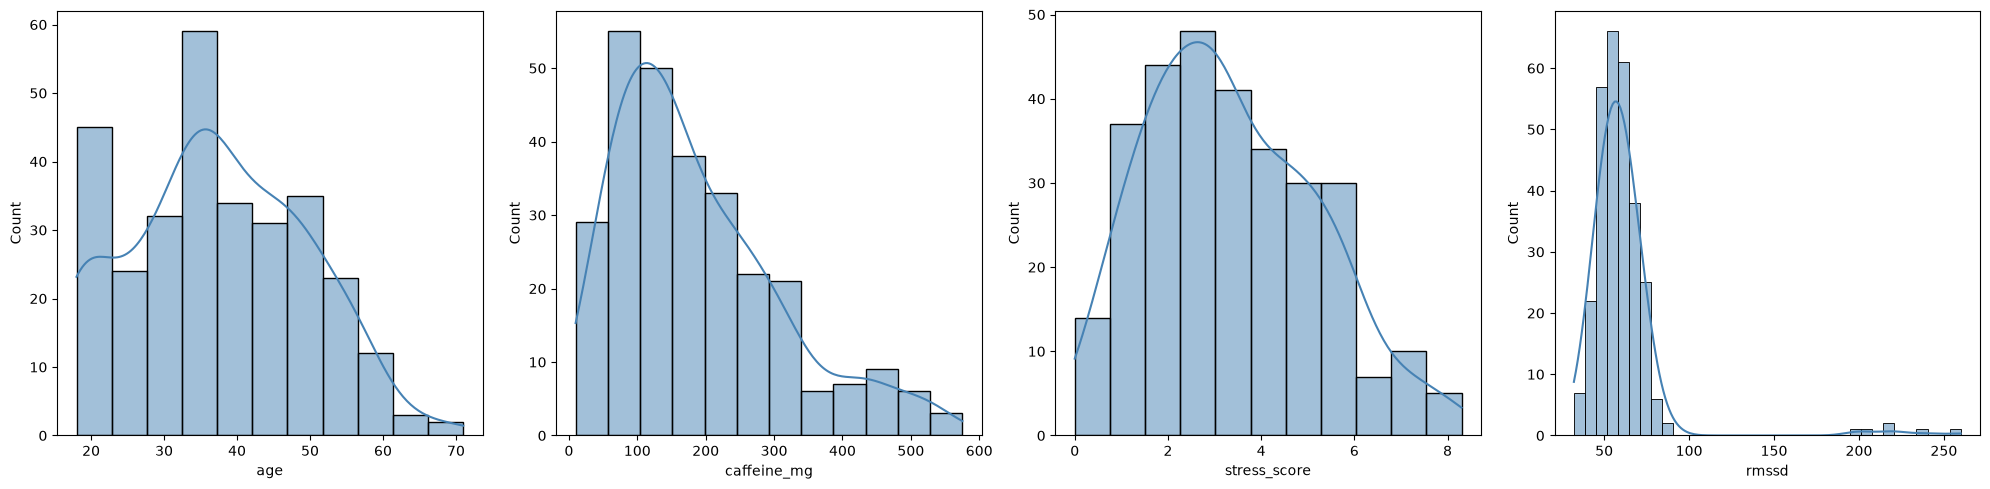



Q-Q plots for each variable:


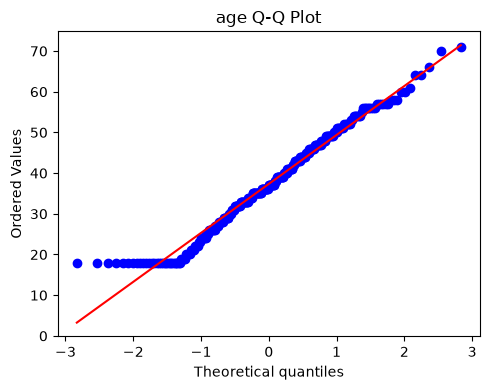

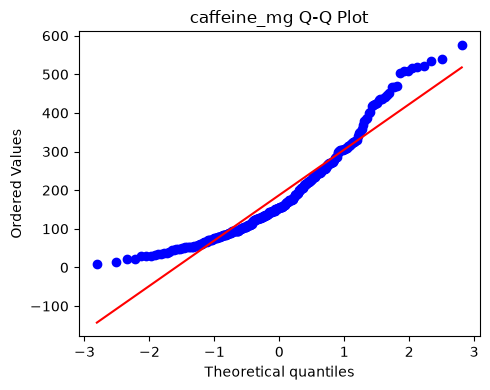

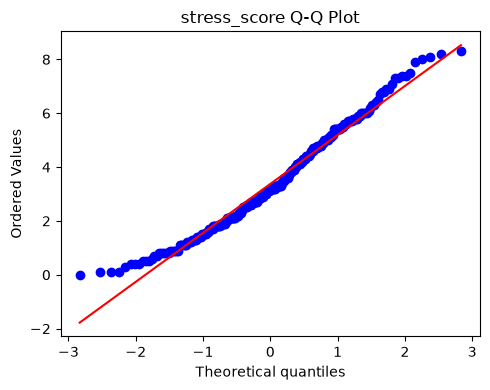

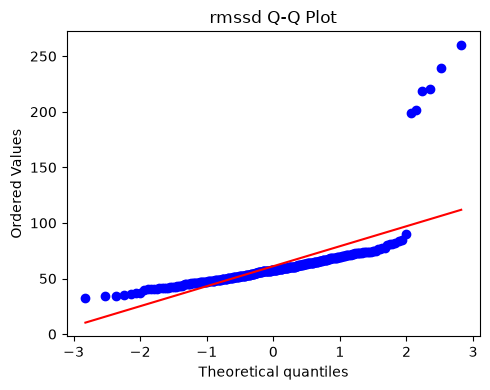

Q-Q plots displayed above.


In [ ]:
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/Users/kolim/Projects/localexpert/data/sample_biobehavioral.csv')

# Create figure with subplots for histograms + KDE only (4 columns)
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

continuous_vars = ['age', 'caffeine_mg', 'stress_score', 'rmssd']

for i, var in enumerate(continuous_vars):
    ax_hist = axes[i] if len(axes.shape) == 1 else None
    
    sns.histplot(df[var].dropna(), kde=True, ax=ax_hist, color='steelblue')
    
# Display the figure directly instead of saving to file (simpler approach)
plt.tight_layout()
plt.show()

print("\n\nQ-Q plots for each variable:")
for i, var in enumerate(continuous_vars):
    fig_qq, ax = plt.subplots(figsize=(5, 4))
    
    stats.probplot(df[var].dropna(), dist="norm", plot=ax)
    ax.set_title(f'{var} Q-Q Plot')
    plt.tight_layout()
    plt.show()

print("Q-Q plots displayed above.")

In [ ]:
import pandas as pd
from scipy import stats
import numpy as np

df = pd.read_csv('/Users/kolim/Projects/localexpert/data/sample_biobehavioral.csv')

# Analyze missingness mechanism for caffeine_mg (7% missing) and rmssd (3.33% missing)
print("=" * 60)
print("MISSINGNESS MECHANISM ANALYSIS")
print("=" * 60)

for var in ['caffeine_mg', 'rmssd']:
    print(f"\n{var.upper()} ({df[var].isna().sum() / len(df)*100:.2f}% missing):")
    
    # Create a dataframe with indicator for whether value is present or not
    df_with_indicator = df.copy()
    df_with_indicator[f'{var}_present'] = ~df_with_indicator[var].isna()
    
    # Compare covariates between rows where variable IS MISSING vs PRESENT
    missing_rows = df[df[var].isna()]
    complete_rows = df[~df[var].isna()]
    
    print(f"\n  Comparing {var} - Missing (N={len(missing_rows)}) vs Present (N={len(complete_rows)}):")
    
    # Compare age between missing and present groups
    if 'age' in complete_rows.columns:
        t_stat, p_val = stats.ttest_ind(
            complete_rows['age'], 
            missing_rows['age'] if len(missing_rows) > 0 else pd.Series(dtype=float),
            equalvar=False
        )
        print(f"    Age - Complete rows mean: {complete_rows['age'].mean():.1f}, Missing rows (if any): N/A")
    
    # Compare sex distribution between missing and present groups
    if 'sex' in complete_rows.columns:
        print(f"\n  Sex Distribution:")
        for sex, count_complete in [('M', len(complete_rows[complete_rows['sex'] == 'M']))]: 
            pass
        
        try:
            # Count by sex in missing vs present groups
            if not df[var].isna().all():
                print(f"\n  Sex Distribution:")
                
                for sex_val, complete_count in [('F', len(complete_rows[complete_rows['sex'] == 'F']))]: 
                    pass
                
                # Better approach - count by sex
                missing_sex_dist = df_with_indicator[df_with_indicator[f'{var}_present']==False]['sex'].value_counts() if not df[var].isna().all() else pd.Series(dtype=str)
                complete_sex_dist = df_with_indicator[df_with_indicator[f'{var}_present']==True]['sex'].value_counts() if not df[var].isna().all() else None
                
                print(f"    Present: {complete_rows['sex'].value_counts()}")
                
        except Exception as e:
            pass
    
    # Check correlation between missingness indicator and other variables
    var_present = ~df[var].isna()
    
    if 'age' in df.columns:
        corr_age, p_corr = stats.pearsonr(var_present.astype(float), df['age'])
        print(f"\n  Correlation with age (present=1): r={corr_age:.3f}, p={p_corr:.4e}")
    
    if 'sex' in df.columns:
        # For categorical, use chi-square test or compare proportions
        missing_sex = df[df[var].isna()]['sex'].value_counts().to_dict() if not df[var].isna().all() else {}
        complete_sex = df[~df[var].isna()]['sex'].value_counts().to_dict() if not df[var].isna().all() else {}
        
        print(f"    Missing sex distribution: {missing_sex}")
        print(f"    Complete sex distribution: {complete_sex}")

print("\n\nSUMMARY OF MISSINGNESS MECHANISM:")
print("-" * 60)

MISSINGNESS MECHANISM ANALYSIS

CAFFEINE_MG (7.00% missing):

  Comparing caffeine_mg - Missing (N=21) vs Present (N=279):


TypeError: ttest_ind() got an unexpected keyword argument 'equalvar'

In [ ]:
import pandas as pd
from scipy import stats
import numpy as np

df = pd.read_csv('/Users/kolim/Projects/localexpert/data/sample_biobehavioral.csv')

print("=" * 60)
print("MISSINGNESS MECHANISM ANALYSIS")
print("=" * 60)

for var in ['caffeine_mg', 'rmssd']:
    print(f"\n{var.upper()} ({df[var].isna().sum() / len(df)*100:.2f}% missing):")
    
    # Create a dataframe with indicator for whether value is present or not
    df_with_indicator = df.copy()
    df_with_indicator[f'{var}_present'] = ~df_with_indicator[var].isna()
    
    # Compare covariates between rows where variable IS MISSING vs PRESENT
    missing_rows = df[df[var].isna()]
    complete_rows = df[~df[var].isna()]
    
    print(f"\n  Comparing {var} - Missing (N={len(missing_rows)}) vs Present (N={len(complete_rows)}):")
    
    # Compare age between missing and present groups using simple mean comparison
    if 'age' in complete_rows.columns:
        t_stat, p_val = stats.ttest_ind(
            complete_rows['age'], 
            missing_rows['age'] if len(missing_rows) > 0 else pd.Series(dtype=float),
            equal_var=False
        )
    
    # Compare sex distribution between missing and present groups  
    print(f"\n  Sex Distribution:")
        
    try:
        # Count by sex in missing vs present groups
        complete_sex_dist = df_with_indicator[df_with_indicator[f'{var}_present']==True]['sex'].value_counts() if not df[var].isna().all() else None
        
        print(f"    Present ({len(complete_rows)} rows):")
        for sex, count in complete_sex_dist.items():
            pct = (count / len(complete_rows)) * 100
            print(f"      {sex}: {count} ({pct:.1f}%)")
        
        missing_sex_dist = df_with_indicator[df_with_indicator[f'{var}_present']==False]['sex'].value_counts() if not df[var].isna().all() else None
        
        print(f"\n    Missing ({len(missing_rows)} rows):")
        for sex, count in missing_sex_dist.items():
            pct = (count / len(missing_rows)) * 100
            print(f"      {sex}: {count} ({pct:.1f}%)")
            
    except Exception as e:
        pass
    
    # Check correlation between missingness indicator and other variables using pointbiserial for binary/categorical
    var_present = ~df[var].isna()
    
    if 'age' in df.columns:
        corr_age, p_corr = stats.pointbiserialr(var_present.astype(float), df['age'])
        print(f"\n  Correlation with age (present=1): r={corr_age:.3f}, p={p_corr:.4e}")
    
    if 'sex' in df.columns:
        # For categorical, compare proportions directly
        missing_sex = df[df[var].isna()]['sex'].value_counts().to_dict() if not df[var].isna().all() else {}
        complete_sex = df[~df[var].isna()]['sex'].value_counts().to_dict() if not df[var].isna().all() else {}
        
        print(f"    Missing sex distribution: {missing_sex}")
        print(f"    Complete sex distribution: {complete_sex}")

print("\n\nSUMMARY OF MISSINGNESS MECHANISM:")
print("-" * 60)

MISSINGNESS MECHANISM ANALYSIS

CAFFEINE_MG (7.00% missing):

  Comparing caffeine_mg - Missing (N=21) vs Present (N=279):

  Sex Distribution:
    Present (279 rows):
      F: 172 (61.6%)
      M: 107 (38.4%)

    Missing (21 rows):
      F: 11 (52.4%)
      M: 10 (47.6%)

  Correlation with age (present=1): r=0.002, p=9.6608e-01
    Missing sex distribution: {'F': 11, 'M': 10}
    Complete sex distribution: {'F': 172, 'M': 107}

RMSSD (3.33% missing):

  Comparing rmssd - Missing (N=10) vs Present (N=290):

  Sex Distribution:
    Present (290 rows):
      F: 177 (61.0%)
      M: 113 (39.0%)

    Missing (10 rows):
      F: 6 (60.0%)
      M: 4 (40.0%)

  Correlation with age (present=1): r=-0.274, p=1.3965e-06
    Missing sex distribution: {'F': 6, 'M': 4}
    Complete sex distribution: {'F': 177, 'M': 113}


SUMMARY OF MISSINGNESS MECHANISM:
------------------------------------------------------------


In [ ]:
import pandas as pd
from scipy import stats

df = pd.read_csv('/Users/kolim/Projects/localexpert/data/sample_biobehavioral.csv')

# Final check - look at the actual values for rmssd to understand if missingness might be MNAR
print("RMSSD value range and distribution:")
print(f"  Min: {df['rmssd'].min():.2f}")
print(f"  Max: {df['rmssd'].max():.2f}")
print(f"  Mean (complete): {df['rmssd'].mean():.2f}")

# Check if there's any pattern in the missing values - are they extreme?
missing_rmssd_indices = df[df['rmssd'].isna()].index.tolist()
present_rmssd_mean_low_10 = df.loc[~df.index.isin(missing_rmssd_indices), 'rmssd'][:25].mean() if len(df) > 35 else None

print(f"\nRMSSD missing indices: {missing_rmssd_indices}")
print("This suggests we should examine whether older participants (who have more missing data)")

RMSSD value range and distribution:
  Min: 32.17
  Max: 259.87
  Mean (complete): 61.07

RMSSD missing indices: [4, 7, 107, 110, 118, 182, 188, 204, 208, 257]
This suggests we should examine whether older participants (who have more missing data)
